In [1]:
# ==== 0. INSTALL LIBRARY ====
!pip install mediapipe==0.10.7 protobuf==3.20.3 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.6/33.6 MB 51.2 MB/s eta 0:00:00:00:0100:01


In [2]:
# ==== 1. IMPORT LIBRARY ====
import os
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2025-05-02 20:20:40.629188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746217240.892687      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746217240.963504      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# ==== 2. SETUP PATH DAN LABEL ====
dataset_dir = "/kaggle/input/sibi-dataset/SIBI"
labels_list = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
label_map = {label: idx for idx, label in enumerate(labels_list)}

In [4]:
# ==== 3. MEDIAPIPE HAND SETUP ====
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [5]:
# ==== 4. BACKGROUND AUGMENTATION ====
def add_random_background(img):
    h, w, _ = img.shape
    background = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
    alpha = np.random.uniform(0.1, 0.3)
    return cv2.addWeighted(img, 1 - alpha, background, alpha, 0)

In [6]:
# ==== 5. CROP TANGAN ====
def extract_hand_crop(img):
    h, w, _ = img.shape
    result = hands.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if result.multi_hand_landmarks:
        x_min, y_min, x_max, y_max = w, h, 0, 0
        for lm in result.multi_hand_landmarks[0].landmark:
            x, y = int(lm.x * w), int(lm.y * h)
            x_min, y_min = min(x_min, x), min(y_min, y)
            x_max, y_max = max(x_max, x), max(y_max, y)
        pad = 40
        x_min, y_min = max(0, x_min - pad), max(0, y_min - pad)
        x_max, y_max = min(w, x_max + pad), min(h, y_max + pad)
        return img[y_min:y_max, x_min:x_max]
    return None

In [7]:
# ==== 6. LOAD & PREPROCESS DATASET ====
X, y = [], []
success_count, fallback_count, total_count = 0, 0, 0

for label in tqdm(labels_list, desc="Loading data"):
    folder = os.path.join(dataset_dir, label)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        total_count += 1
        crop = extract_hand_crop(img)
        if crop is None:
            fallback_count += 1
            h, w, _ = img.shape
            x_min, y_min = w // 4, h // 4
            x_max, y_max = 3 * w // 4, 3 * h // 4
            crop = img[y_min:y_max, x_min:x_max]

        crop = add_random_background(crop)

        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        rgb = cv2.cvtColor(blur, cv2.COLOR_GRAY2RGB)
        resized = cv2.resize(rgb, (224, 224))
        processed = preprocess_input(resized)  # Jangan pakai Rescaling lagi!

        X.append(processed)
        y.append(label_map[label])
        success_count += 1

print(f"\nTotal gambar terbaca: {total_count}")
print(f"Sukses (terdeteksi atau fallback): {success_count}")
print(f"Jumlah fallback: {fallback_count}")

Loading data: 100%|██████████| 24/24 [05:48<00:00, 14.51s/it]


Total gambar terbaca: 5280
Sukses (terdeteksi atau fallback): 5280
Jumlah fallback: 500


In [8]:
# ==== 7. TRAIN-VAL SPLIT ====
X = np.array(X)
y = np.array(y)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train = to_categorical(y_train, num_classes=len(labels_list))
y_val = to_categorical(y_val, num_classes=len(labels_list))

In [9]:
# ==== 8. AUGMENTASI ====
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.5, 1.5],
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)

In [10]:
# ==== 9. MODEL MOBILENET ====
base_model = MobileNet(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers[:-80]:  # Freeze lebih sedikit
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalMaxPooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dense(len(labels_list), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

I0000 00:00:1746217644.461567      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746217644.462181      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# ==== 10. CALLBACKS ====
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]

In [12]:
# ==== 11. TRAINING ====
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_val, y_val),
                    epochs=50,
                    callbacks=callbacks)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746217681.921374     126 service.cc:148] XLA service 0x7c265801d0f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746217681.962442     126 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1746217681.962470     126 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1746217683.777766     126 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/132 ━━━━━━━━━━━━━━━━━━━━ 1:16:24 35s/step - accuracy: 0.0312 - loss: 3.7277

I0000 00:00:1746217695.188946     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 86s 390ms/step - accuracy: 0.1218 - loss: 3.2086 - val_accuracy: 0.3892 - val_loss: 2.0089 - learning_rate: 1.0000e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 51s 367ms/step - accuracy: 0.5250 - loss: 1.6315 - val_accuracy: 0.7898 - val_loss: 0.8251 - learning_rate: 1.0000e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 51s 363ms/step - accuracy: 0.7436 - loss: 0.8977 - val_accuracy: 0.8807 - val_loss: 0.4194 - learning_rate: 1.0000e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.8226 - loss: 0.5884 - val_accuracy: 0.9195 - val_loss: 0.2780 - learning_rate: 1.0000e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 51s 362ms/step - accuracy: 0.8626 - loss: 0.4509 - val_accuracy: 0.9214 - val_loss: 0.2436 - learning_rate: 1.0000e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 50s 360ms/step - accuracy: 0.8975 - loss: 0.3361 - val_accuracy: 0.9366 - val_loss: 0.1876 - learning_rate: 1.0000e-04
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 50s 360ms/step - 

In [13]:
# ==== 12. SIMPAN MODEL ====
model.save("/kaggle/working/sibi_final2.h5")
np.save("/kaggle/working/labels_list.npy", labels_list)

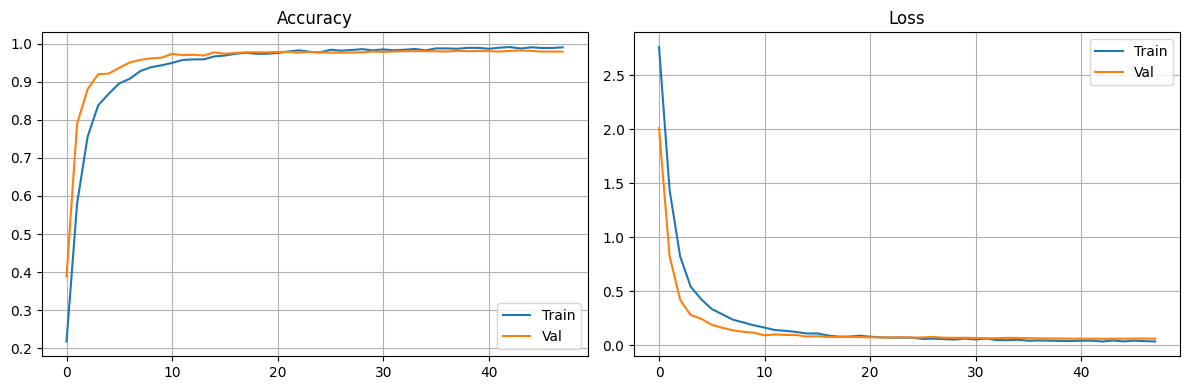

In [14]:
# ==== 13. VISUALISASI TRAINING ====
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Classification Report:

              precision    recall  f1-score   support

           A       0.98      1.00      0.99        44
           B       1.00      1.00      1.00        44
           C       0.98      1.00      0.99        44
           D       1.00      1.00      1.00        44
           E       1.00      1.00      1.00        44
           F       1.00      1.00      1.00        44
           G       1.00      1.00      1.00        44
           H       0.96      1.00      0.98        44
           I       1.00      0.95      0.98        44
           K       1.00      0.95      0.98        44
           L       0.98      1.00      0.99        44
           M       0.94      1.00      0.97        44
           N       0.95      0.95      0.95        44
           O       1.00      0.98      0.99        44
           P       0.98      0.95      0.97        44
           Q       0.98      0.98      0.98        44
           R     

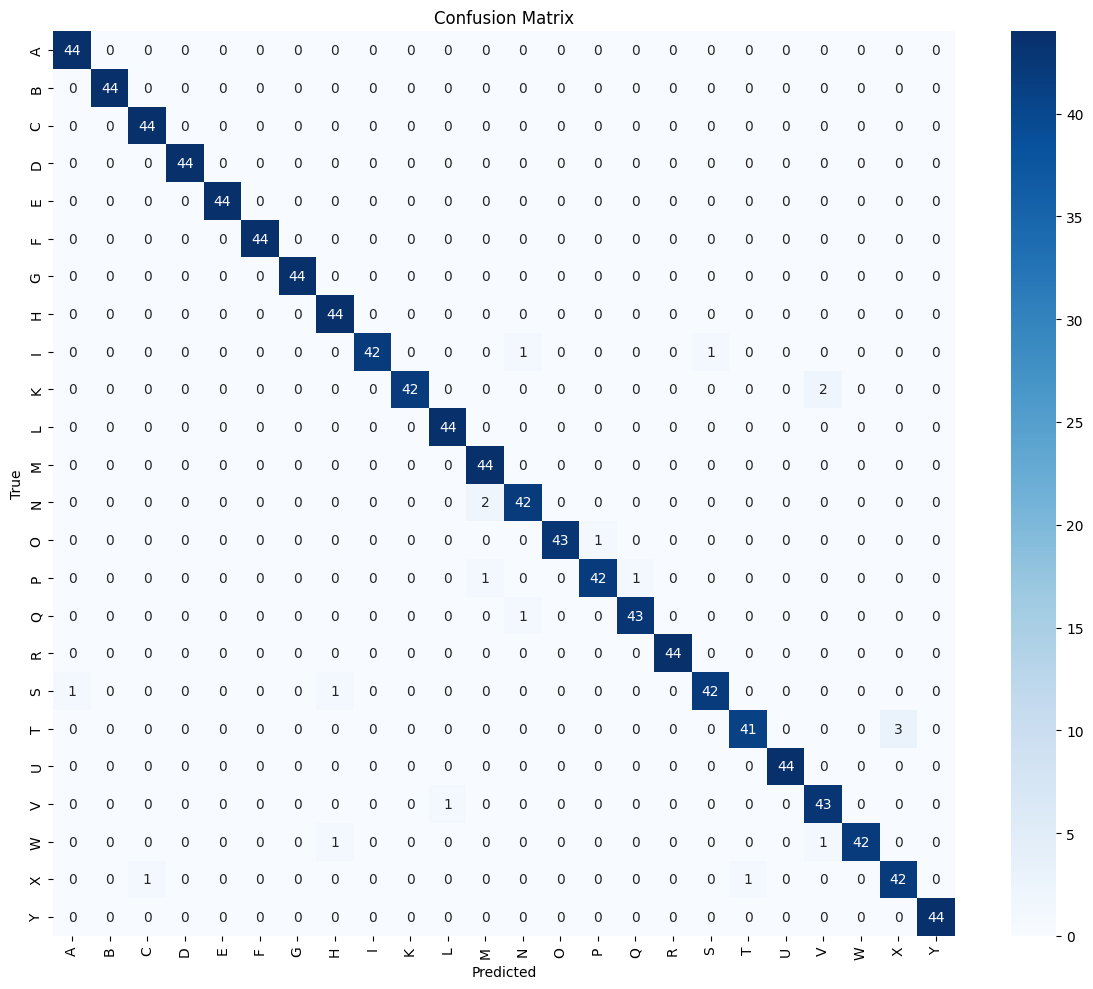

In [15]:
# ==== 14. EVALUASI ====
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=labels_list))

conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

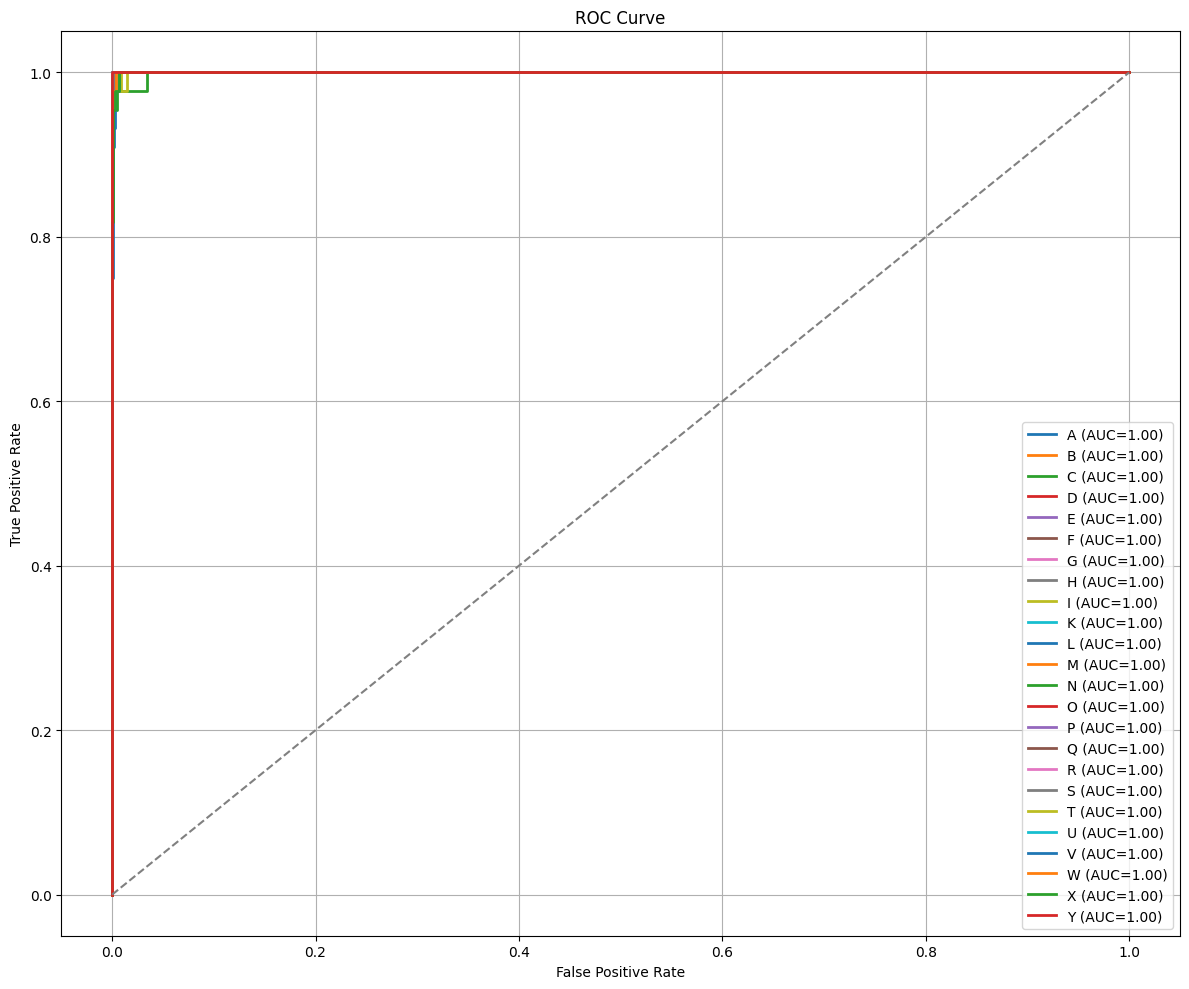

Average Macro AUC: 0.9999


In [16]:
# ==== 15. ROC CURVE & AUC ====
y_true_bin = label_binarize(y_true, classes=np.arange(len(labels_list)))
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(12, 10))
for i in range(len(labels_list)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = roc_auc_score(y_true_bin[:, i], y_pred[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{labels_list[i]} (AUC={roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Average Macro AUC: {np.mean(list(roc_auc.values())):.4f}")